In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, plot_roc_curve

In [2]:
# Load data
file = "../feature_tsv/feature_pruned_withNA.tsv"
df = pd.read_csv(file, delimiter="\t")
df

,PPARD_rs4713859,LRP5_rs3736228,CSNK1A1_rs10476909,CSNK1A1_rs1379544,CSNK1A1_rs447950,CSNK1A1_rs414582,CSNK1A1_rs3733658,CSNK1A1_rs2400891,CSNK1A1_rs10062536,LRP5_rs4988300,...,CADD_max_PPARD,CADD_max_PRKCD,SEX_N_MALE,RADIATION_STATUS_N,AGE_MTX_INITIATION_YEAR,PC1,PC2,PC3,PC4,phenotype
0,0,0,1,1,0,0,1,1,0,0,...,13.94,6.272,0.0,0.0,10.983562,-0.008191,-0.018680,0.005815,-0.007583,0
1,0,1,1,0,1,0,0,0,0,1,...,13.94,6.272,0.0,0.0,7.997268,-0.008189,-0.018549,0.008773,-0.008295,0
2,0,0,0,2,0,0,2,2,0,0,...,13.94,12.370,1.0,0.0,2.528767,-0.008197,-0.018704,0.008160,-0.007941,0
3,0,0,0,1,1,1,1,1,1,0,...,13.94,6.272,1.0,1.0,16.498630,-0.000459,-0.013120,0.008233,0.012657,0
4,0,0,1,1,0,0,2,2,0,1,...,13.94,6.272,0.0,0.0,1.802740,-0.008050,-0.019170,0.007359,-0.009525,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,0,0,1,2,0,0,2,2,0,2,...,13.94,8.324,0.0,0.0,4.082192,-0.006296,-0.017952,0.009310,0.002128,0
274,0,0,0,0,1,1,0,0,1,2,...,13.94,6.272,1.0,0.0,8.972603,-0.004892,-0.016423,0.009984,0.006774,0
275,0,0,0,0,1,0,1,1,0,0,...,13.94,12.370,0.0,0.0,8.027322,-0.007780,-0.018166,0.007905,-0.005000,0
276,0,0,0,1,1,0,1,1,0,0,...,13.94,12.370,1.0,0.0,7.297814,-0.007948,-0.019062,0.008278,-0.009083,0


In [3]:
#check NA
df.isna().sum().sum()

160

In [4]:
# Check for None
df.applymap(lambda x: x=="").sum().sum()

0

In [5]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(df.drop('phenotype', axis=1), df["phenotype"], test_size=0.2, random_state=0)

In [6]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost classifier
clf = xgb.XGBClassifier(objective="binary:logistic", random_state=0, eval_metric='logloss')

# Hyperparameter grid
params = {
    'n_estimators': [10, 40, 50, 60, 100, 110],
    'max_depth': np.arange(2, 7, 1),
    'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5],
    'alpha': [0, 0.5, 1],
    'lambda': [1, 1.5, 2]
}

# Perform Grid Search
grid_search = GridSearchCV(clf, params, cv=5, n_jobs=-1, scoring="roc_auc")
grid_search.fit(X_train, y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")


Best parameters: {'alpha': 0, 'lambda': 1.5, 'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 10}
Best ROC AUC Score: 0.7184083658277207


In [7]:
grid_search.best_params_

{'alpha': 0,
 'lambda': 1.5,
 'learning_rate': 0.5,
 'max_depth': 3,
 'n_estimators': 10}

#### Save the result

In [8]:
best_model_gbdt_withNA = grid_search.best_estimator_
%store best_model_gbdt_withNA

Stored 'best_model_gbdt_withNA' (XGBClassifier)


In [9]:
%store -r best_model_gbdt_withNA

#### Feature Importance

In [10]:
def plot_top_feature_importance(importances, column_names, top_n=20):
         feature_important_series = pd.Series(importances, index=column_names)
         
         # Sort and take the top_n features
         sorted_importances = feature_important_series.sort_values(ascending=False)[0:top_n].iloc[::-1]
         
         # Normalize 
         sorted_importances = 100.0 * (sorted_importances/sorted_importances.max())
         
         plt.figure(figsize=(20,6))
         sorted_importances.plot(kind="barh")
         plt.xlabel('Relative Importance')
         plt.title(f'Top {top_n} Variable Importance')

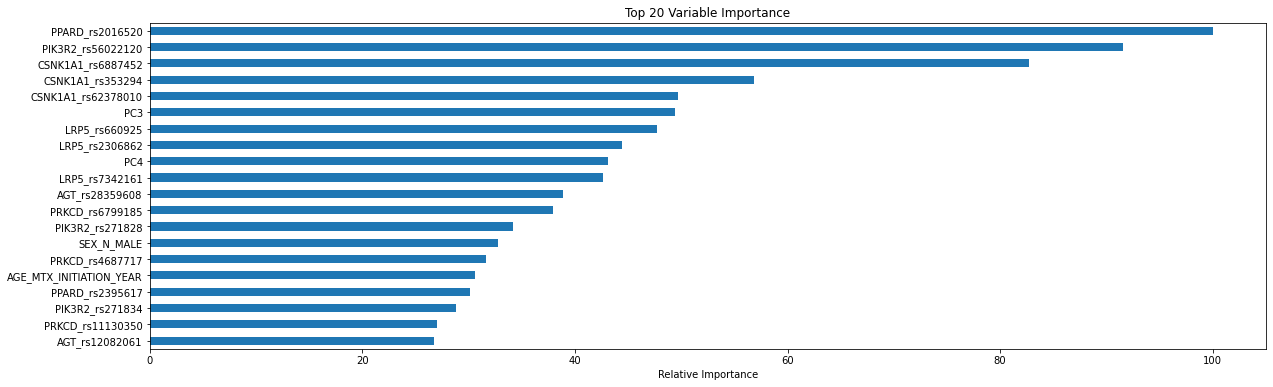

In [11]:
feature_importance = best_model_gbdt_withNA.feature_importances_
feature_names = df.drop("phenotype", axis=1).columns

top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
plt.savefig("../plot/top_importance_full_subject_removed.pdf")

#### Performance Evaluation
* ROC-AUC curve plotting

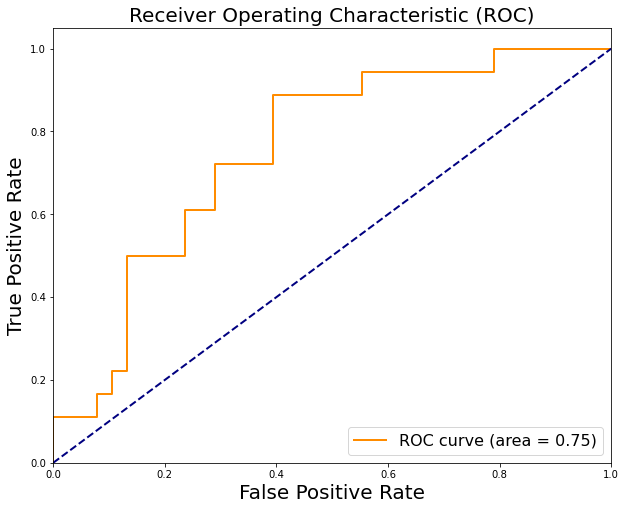

In [12]:
def plot_roc_auc(y_true, y_pred_prob, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=20)
    plt.ylabel('True Positive Rate', fontsize=20)
    plt.title('Receiver Operating Characteristic (ROC)',fontsize=20)
    plt.legend(loc='lower right', fontsize=16)
    
    if save_path:
        plt.savefig(save_path)
    
    plt.show()
    
if __name__ == "__main__":
    #Predict probabilityes of positive class of each instance
    positive_prob = best_model_gbdt_withNA.predict_proba(X_test)[:,1]

    plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_full_nomissingsubjects.pdf")

Text(0.5, 15.0, 'Predicted')

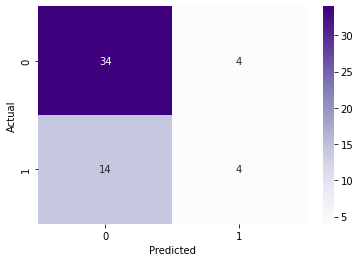

In [13]:
# confusion matrix
y_pred = best_model_gbdt_withNA.predict(X_test)
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt="d", cmap="Purples", xticklabels=[0,1], yticklabels=[0,1])
plt.ylabel('Actual')
plt.xlabel('Predicted')

npv: 0.71, ppv:0.50, sensitivty0.22, specificity0.89, f1 score0.31


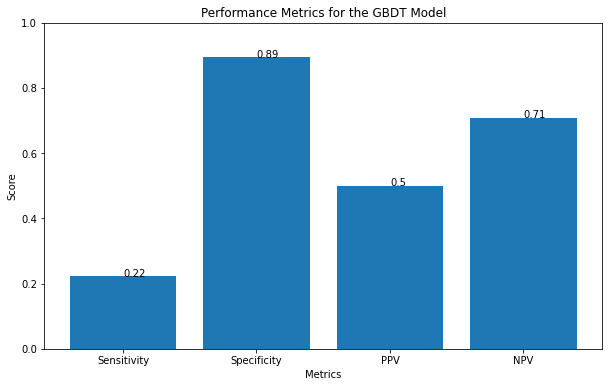

In [14]:
y_pred = best_model_gbdt_withNA.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# sensitivity aka recall
sensitivity = recall

# specificity
tn, fp, fn, tp = conf.ravel() 
specificity  = tn/(tn+fp)

#ppv 
ppv = tp/(tp+fp)
#npv
npv = tn/(tn+fn)

metrics = [sensitivity, specificity, ppv, npv]
metric_names = ['Sensitivity', 'Specificity', 'PPV', 'NPV']

plt.figure(figsize=(10,6))
plt.bar(metric_names, metrics)
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim([0, 1])
plt.title('Performance Metrics for the GBDT Model')
for index, value in enumerate(metrics):
    plt.text(index, value, str(round(value, 2)))
plt.savefig("../plot/GBDT_performance_subject_removed.pdf")
print(f"npv: {npv:0.2f}, ppv:{ppv:0.2f}, sensitivty{sensitivity:0.2f}, specificity{specificity:0.2f}, f1 score{f1:0.2f}")

#### Ablation Test (without genetic variants)

In [15]:
X_test_ablated = X_test.iloc[:,-7:]
X_train_ablated = X_train.iloc[:,-7:] 

In [16]:
# Initialize XGBoost classifier
clf = xgb.XGBClassifier(objective="binary:logistic", random_state=0, eval_metric='logloss')

# Hyperparameter grid
params = {
    'n_estimators': [10, 40, 50, 60, 100, 110],
    'max_depth': np.arange(2, 7, 1),
    'learning_rate': [0.01, 0.1, 0.2, 0.3, 0.4, 0.5],
    'alpha': [0, 0.5, 1],
    'lambda': [1, 1.5, 2]
}

# Perform Grid Search
grid_search = GridSearchCV(clf, params, cv=5, n_jobs=-1, scoring="roc_auc")
grid_search.fit(X_train_ablated , y_train)

# Get the best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters: {best_params}")
print(f"Best ROC AUC Score: {best_score}")


Best parameters: {'alpha': 0, 'lambda': 1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 40}
Best ROC AUC Score: 0.5931100082712987


In [17]:
best_model_withNA_ablated = grid_search.best_estimator_
%store best_model_withNA_ablated

Stored 'best_model_withNA_ablated' (XGBClassifier)


In [18]:
%store -r best_model_withNA_ablated 

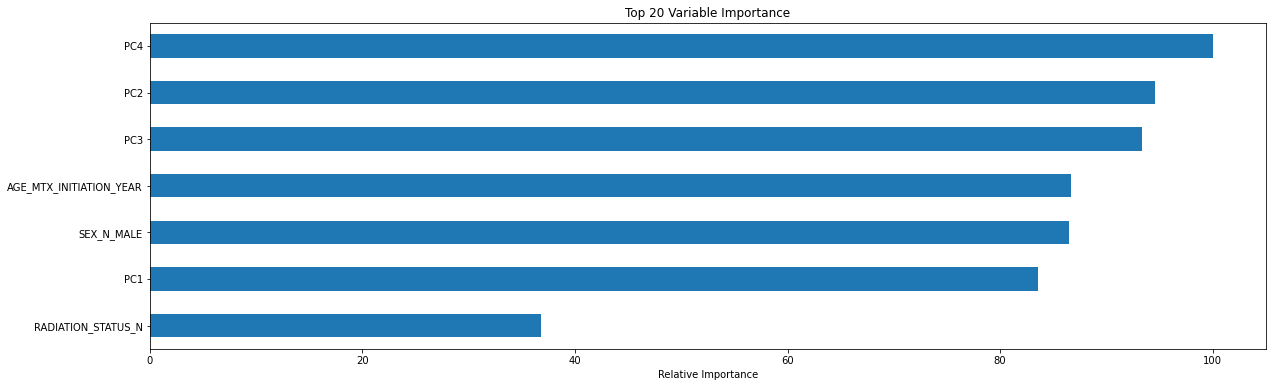

In [19]:
feature_importance = best_model_withNA_ablated.feature_importances_
feature_names = X_train_ablated.columns

top_importance = plot_top_feature_importance(feature_importance, feature_names, 20)
plt.savefig("../plot/top_importance_full_withNA_ablated.pdf")

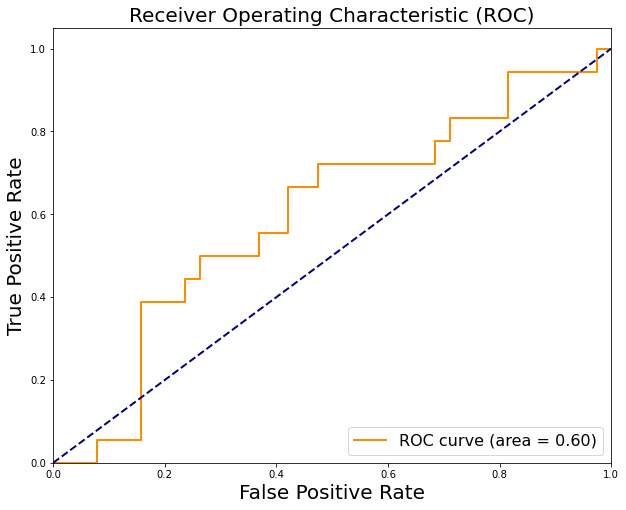

In [20]:
#Predict probabilityes of positive class of each instance
positive_prob = best_model_withNA_ablated.predict_proba(X_test_ablated)[:,1]

plot_roc_auc(y_test, positive_prob, save_path="../plot/ROC_AUC_ablated_nomissingsubjects.pdf")